# Circuits for Lesson 6 of the Tutorial (Part 4)

The 22 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 6 of the Tutorial (Part 4)*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.16'

## 1. Bo2's Drill Exercise 6.4 (DC)

The is-the-textbook-wrong problem, over four entries. First interval in DC: il = 2 A and vc = 0.

![The circuit of Bo2's Drill Exercise 6.4 (DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-4-35.jpg)

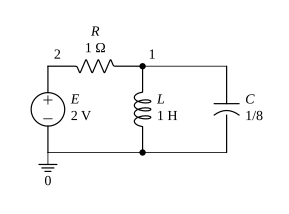

In [3]:
c1 = '''
e,2,0,2
r,1,2,1
l,1,0,1
c,1,0,1/8
'''
draw(c1)

In [4]:
r1 = dc(c1)
r1

Result(domain='dc')
  i_c = 0
  i_e = -2
  i_l = 2
  i_r = -2
  p_c = 0
  p_e = -4
  p_l = 0
  p_r = 4
  r_e = 1
  v_1 = 0
  v_2 = 2
  v_c = 0
  v_e = 2
  v_l = 0
  v_r = -2

## 2. Bo2's Drill Exercise 6.4 (TR, the book's 1 H)

Solve with the schematic's inductor and compare with the printed answer. This is the point of the problem: the schematic says 1 H and the answer disagrees with the printed one.

![The circuit of Bo2's Drill Exercise 6.4 (TR, the book's 1 H)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-4-35.jpg)

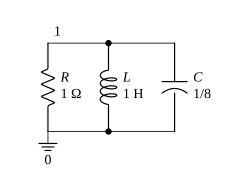

In [5]:
c2 = '''
r,1,0,1
l,1,0,1,2
c,1,0,1/8,0
'''
draw(c2)

In [6]:
r2 = tr(c2)
r2

Result(domain='tr')
  i_c = 2*(sqrt(2)*sinh(2*sqrt(2)*t) - cosh(2*sqrt(2)*t))*exp(-4*t)
  i_l = 2*(sqrt(2)*sinh(2*sqrt(2)*t) + cosh(2*sqrt(2)*t))*exp(-4*t)
  i_r = -4*sqrt(2)*exp(-4*t)*sinh(2*sqrt(2)*t)
  v_1 = -4*sqrt(2)*exp(-4*t)*sinh(2*sqrt(2)*t)

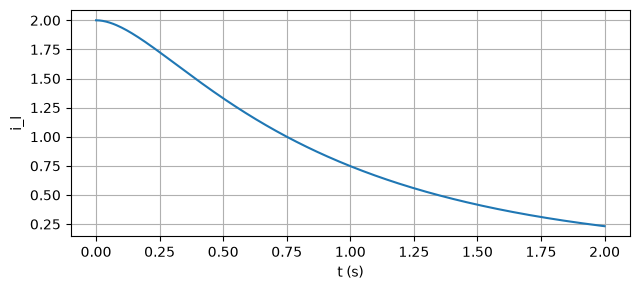

In [7]:
ts, ys = time_samples(c2, 'i_l', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 3. Bo2's Drill Exercise 6.4 (TR, 1/2 H instead)

The same TR run with the inductor at 1/2 H. With half a henry the answer matches, so the schematic is wrong and the previous owner's pencilled correction right.

![The circuit of Bo2's Drill Exercise 6.4 (TR, 1/2 H instead)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-4-35.jpg)

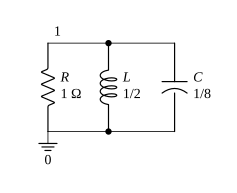

In [8]:
c3 = '''
r,1,0,1
l,1,0,1/2,2
c,1,0,1/8,0
'''
draw(c3)

In [9]:
r3 = tr(c3)
r3

Result(domain='tr')
  i_c = 2*(4*t - 1)*exp(-4*t)
  i_l = 2*(4*t + 1)*exp(-4*t)
  i_r = -16*t*exp(-4*t)
  v_1 = -16*t*exp(-4*t)

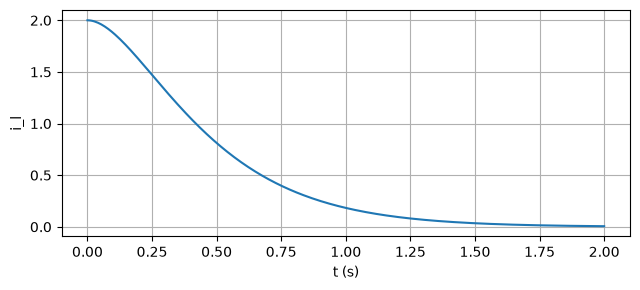

In [10]:
ts, ys = time_samples(c3, 'i_l', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 4. Bo2's Drill Exercise 6.4 (FD, solving for the inductor)

Reverse-engineering the inductance: transform the book's answer with t2s, solve the s-domain vc against it.

![The circuit of Bo2's Drill Exercise 6.4 (FD, solving for the inductor)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-4-35.jpg)

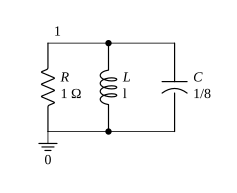

In [11]:
c4 = '''
r,1,0,1
l,1,0,l,2
c,1,0,1/8,0
'''
draw(c4)

In [12]:
r4 = fd(c4)
r4

Result(domain='fd')
  i_c = -2*l*s/(l*s**2 + 8*l*s + 8)
  i_l = 2*l*(s + 8)/(l*s**2 + 8*l*s + 8)
  i_r = -16*l/(l*s**2 + 8*l*s + 8)
  v_1 = -16*l/(l*s**2 + 8*l*s + 8)

In [13]:
solve(r4, ['-16/(s+4)^2 = vc'], ['l'])

[{'l': 1/2}]

## 5. Bo2's Drill Exercise 6.5 (DC)

The source drops from 12 V at t = 0. Find i2(t) for t >= 0; this DC interval gives il1 = 2 A and il2 = 0.

![The circuit of Bo2's Drill Exercise 6.5 (DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-5-36.jpg)

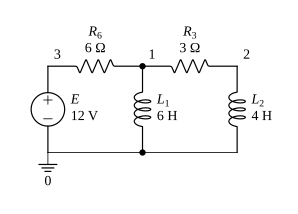

In [14]:
c5 = '''
e,3,0,12
r6,3,1,6
l1,1,0,6
r3,1,2,3
l2,2,0,4
'''
draw(c5)

In [15]:
r5 = dc(c5)
r5

Result(domain='dc')
  i_e = -2
  i_l1 = 2
  i_l2 = 0
  i_r3 = 0
  i_r6 = 2
  p_e = -24
  p_l1 = 0
  p_l2 = 0
  p_r3 = 0
  p_r6 = 24
  r_e = 6
  v_1 = 0
  v_2 = 0
  v_3 = 12
  v_e = 12
  v_l1 = 0
  v_l2 = 0
  v_r3 = 0
  v_r6 = 12

## 6. Bo2's Drill Exercise 6.5 (TR)

Second interval in TR: il2 comes back (12/11)(e^(-3t) - e^(-t/4)).

![The circuit of Bo2's Drill Exercise 6.5 (TR)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-5-36.jpg)

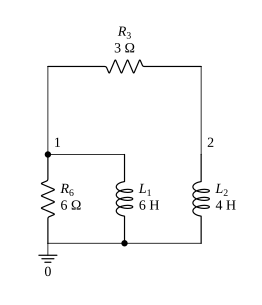

In [16]:
c6 = '''
r6,0,1,6
l1,1,0,6,2
r3,1,2,3
l2,2,0,4,0
'''
draw(c6)

In [17]:
r6 = tr(c6)
r6

Result(domain='tr')
  i_l1 = 6*exp(-3*t)/11 + 16*exp(-t/4)/11
  i_l2 = 12*exp(-3*t)/11 - 12*exp(-t/4)/11
  i_r3 = 12*exp(-3*t)/11 - 12*exp(-t/4)/11
  i_r6 = 18*exp(-3*t)/11 + 4*exp(-t/4)/11
  v_1 = -108*exp(-3*t)/11 - 24*exp(-t/4)/11
  v_2 = -144*exp(-3*t)/11 + 12*exp(-t/4)/11

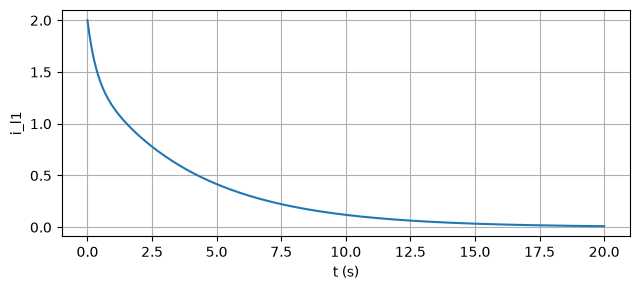

In [18]:
ts, ys = time_samples(c6, 'i_l1', 20, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l1'); plt.grid(True); plt.tight_layout()

## 7. Bo2's Drill Exercise 6.6 (Op Amp, DC)

Two capacitors around an op amp. Find vo(t) for t >= 0; this DC interval gives vca = 0 and vcb = 4 V.

![The circuit of Bo2's Drill Exercise 6.6 (Op Amp, DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-6-op-amp-37.jpg)

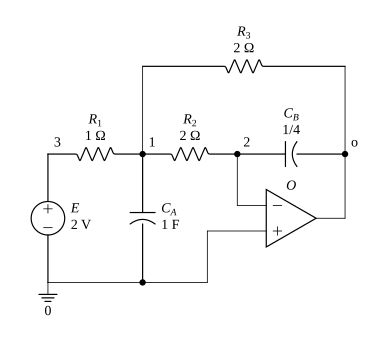

In [19]:
c7 = '''
e,3,0,2
r1,3,1,1
r2,1,2,2
r3,1,o,2
ca,1,0,1
cb,2,o,1/4
o,0,2,o
'''
draw(c7)

In [20]:
r7 = dc(c7)
r7

Result(domain='dc')
  i_ca = 0
  i_cb = 0
  i_e = -2
  i_o = -2
  i_r1 = 2
  i_r2 = 0
  i_r3 = 2
  p_ca = 0
  p_cb = 0
  p_e = -4
  p_o = -8
  p_r1 = 4
  p_r2 = 0
  p_r3 = 8
  r_e = 1
  v_1 = 0
  v_2 = 0
  v_3 = 2
  v_ca = 0
  v_cb = 4
  v_e = 2
  v_o = -4
  v_r1 = 2
  v_r2 = 0
  v_r3 = 4

## 8. Bo2's Drill Exercise 6.6 (Op Amp, TR)

Second interval in TR: vo comes back (-4t-4)e^(-t).

![The circuit of Bo2's Drill Exercise 6.6 (Op Amp, TR)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-6-op-amp-37.jpg)

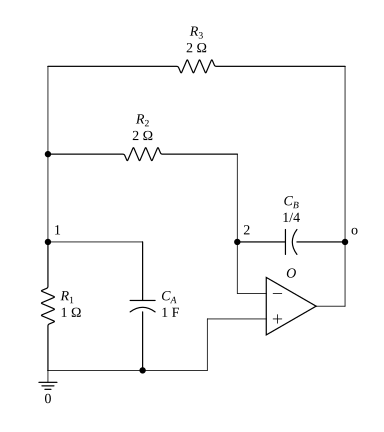

In [21]:
c8 = '''
r1,0,1,1
r2,1,2,2
r3,1,o,2
ca,1,0,1,0
cb,2,o,1/4,4
o,0,2,o
'''
draw(c8)

In [22]:
r8 = tr(c8)
r8

Result(domain='tr')
  i_ca = 2*(t - 1)*exp(-t)
  i_cb = -t*exp(-t)
  i_o = -2*exp(-t)
  i_r1 = 2*t*exp(-t)
  i_r2 = -t*exp(-t)
  i_r3 = (t + 2)*exp(-t)
  v_1 = -2*t*exp(-t)
  v_2 = 0
  v_o = 4*(-t - 1)*exp(-t)

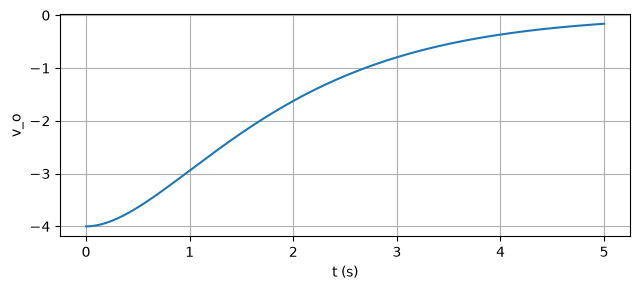

In [23]:
ts, ys = time_samples(c8, 'v_o', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

## 9. Bo2's Example 6.5 (Plot)

In this problem, we use the Plot card for the first time: find v(t) and i(t) for the series RLC, then plot each between 0 and 1.5 s. The Plot card takes an answer's name rather than an expression, so v_c. Plot i_l the same way for the current.

![The circuit of Bo2's Example 6.5 (Plot)](https://learn.symbulator.com/assets/practice/bo2s-example-6-5-plot-38.jpg)

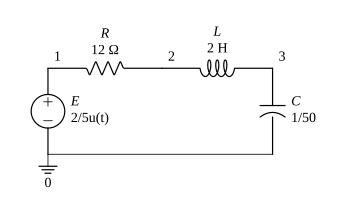

In [24]:
c9 = '''
e,1,0,2/5*u(t)
r,1,2,12
l,2,3,2,0
c,3,0,1/50,0
'''
draw(c9)

In [25]:
r9 = tr(c9)
r9

Result(domain='tr')
  i_c = exp(-3*t)*sin(4*t)/20
  i_e = -exp(-3*t)*sin(4*t)/20
  i_l = exp(-3*t)*sin(4*t)/20
  i_r = exp(-3*t)*sin(4*t)/20
  v_1 = 2/5
  v_2 = 2/5 - 3*exp(-3*t)*sin(4*t)/5
  v_3 = (4*exp(3*t) - 3*sin(4*t) - 4*cos(4*t))*exp(-3*t)/10

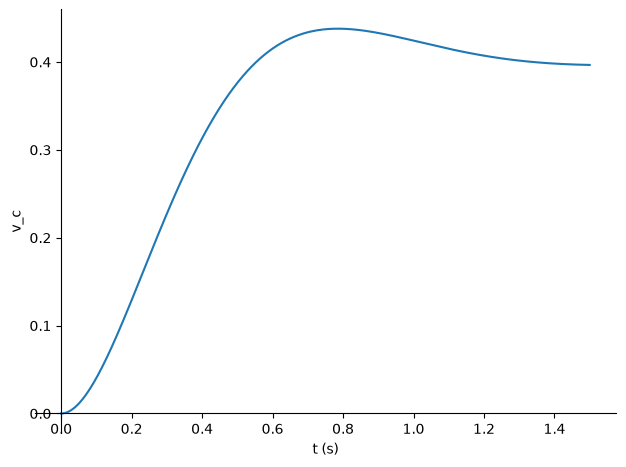

In [26]:
d = tr(c9, variables=['v_3'])
sp.plot(d['v_3'] - 0, (t, 0, 1.5), xlabel='t (s)', ylabel='v_c');

## 10. Bo2's Drill Exercise 6.7

The same series RLC with vs = 3 V, R = 5, L = 1/2 and C = 1/8: find v(t) and i(t) — read vc and il.

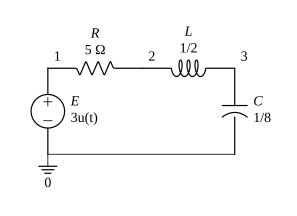

In [27]:
c10 = '''
e,1,0,3*u(t)
r,1,2,5
l,2,3,1/2,0
c,3,0,1/8,0
'''
draw(c10)

In [28]:
r10 = tr(c10)
r10

Result(domain='tr')
  i_c = (exp(6*t) - 1)*exp(-8*t)
  i_e = (1 - exp(6*t))*exp(-8*t)
  i_l = (exp(6*t) - 1)*exp(-8*t)
  i_r = (exp(6*t) - 1)*exp(-8*t)
  v_1 = 3
  v_2 = 3 - 5*exp(-2*t) + 5*exp(-8*t)
  v_3 = 3 - 4*exp(-2*t) + exp(-8*t)

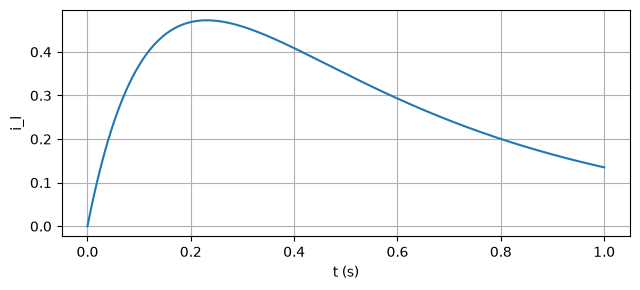

In [29]:
ts, ys = time_samples(c10, 'i_l', 1, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 11. Bo2's Drill Exercise 6.8 (Ramp)

The circuit of the previous entry with a ramp source, 3t: find vc.

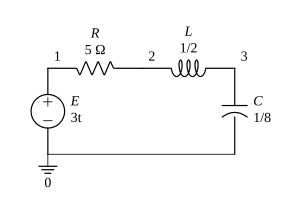

In [30]:
c11 = '''
e,1,0,3t
r,1,2,5
l,2,3,1/2,0
c,3,0,1/8,0
'''
draw(c11)

In [31]:
r11 = tr(c11)
r11

Result(domain='tr')
  i_c = 3/8 - exp(-2*t)/2 + exp(-8*t)/8
  i_e = -3/8 + exp(-2*t)/2 - exp(-8*t)/8
  i_l = 3/8 - exp(-2*t)/2 + exp(-8*t)/8
  i_r = 3/8 - exp(-2*t)/2 + exp(-8*t)/8
  v_1 = 3*t
  v_2 = 3*t - 15/8 + 5*exp(-2*t)/2 - 5*exp(-8*t)/8
  v_3 = 3*t - 15/8 + 2*exp(-2*t) - exp(-8*t)/8

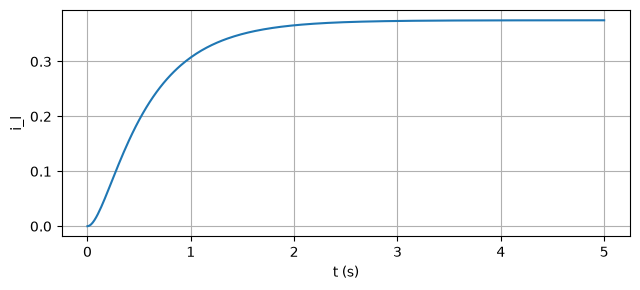

In [32]:
ts, ys = time_samples(c11, 'i_l', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 12. Bo2's Example 6.6 (Plot, DC)

First interval, with the switch closed as a short: DC gives il = 4 A and vc = 0.

![The circuit of Bo2's Example 6.6 (Plot, DC)](https://learn.symbulator.com/assets/practice/bo2s-example-6-6-plot-40.jpg)

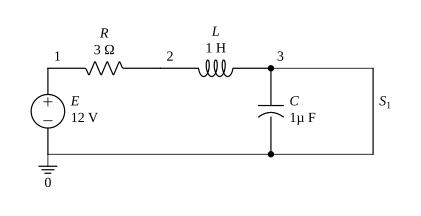

In [33]:
c12 = '''
e,1,0,12
r,1,2,3
l,2,3,1
c,3,0,1'µ
s1,3,0
'''
draw(c12)

In [34]:
r12 = dc(c12)
r12

Result(domain='dc')
  i_c = 0
  i_e = -4
  i_l = 4
  i_r = 4
  i_s1 = 4
  p_c = 0
  p_e = -48
  p_l = 0
  p_r = 48
  r_e = 3
  v_1 = 12
  v_2 = 0
  v_3 = 0
  v_c = 0
  v_e = 12
  v_l = 0
  v_r = 12

## 13. Bo2's Example 6.6 (Plot, TR)

Second interval: plot the inductor's voltage between 0 and 5 ms. Worth plotting: a 12 V source, and the inductor swings to 3990.6 V at t = 1.57 ms -- which is the chapter's 'around 1.57 ms ... 3991 volts', measured.

![The circuit of Bo2's Example 6.6 (Plot, TR)](https://learn.symbulator.com/assets/practice/bo2s-example-6-6-plot-40.jpg)

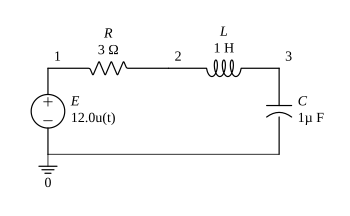

In [35]:
c13 = '''
e,1,0,12.0*u(t)
r,1,2,3
l,2,3,1,4
c,3,0,1'µ,0
'''
draw(c13)

In [36]:
r13 = tr(c13)
r13

Result(domain='tr')
  i_c = (0.00600000675001139*sin(999.998874999367*t) + 4.0*cos(999.998874999367*t))*exp(-1.5*t)
  i_e = -(0.00600000675001139*sin(999.998874999367*t) + 4.0*cos(999.998874999367*t))*exp(-1.5*t)
  i_l = (0.00600000675001139*sin(999.998874999367*t) + 4.0*cos(999.998874999367*t))*exp(-1.5*t)
  i_r = (0.00600000675001139*sin(999.998874999367*t) + 4.0*cos(999.998874999367*t))*exp(-1.5*t)
  v_1 = 12.0000000000000
  v_2 = (12.0*exp(1.5*t) - 0.0180000202500342*sin(999.998874999367*t) - 12.0*cos(999.998874999367*t))*exp(-1.5*t)
  v_3 = (12.0*exp(1.5*t) + 3999.98649998734*sin(999.998874999367*t) - 12.0*cos(999.998874999367*t))*exp(-1.5*t)

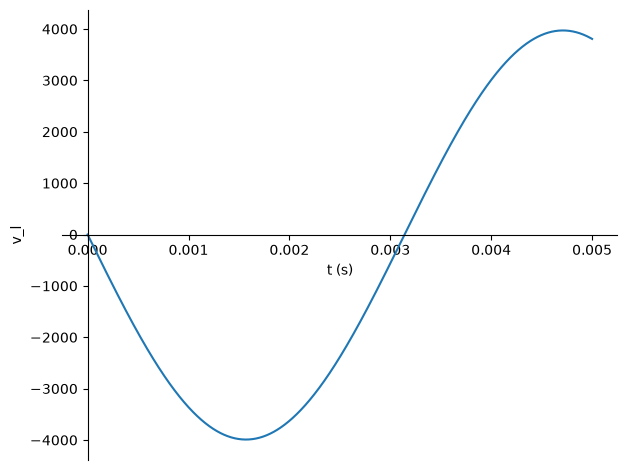

In [37]:
d = tr(c13, variables=['v_2', 'v_3'])
sp.plot(d['v_2'] - d['v_3'], (t, 0, 0.005), xlabel='t (s)', ylabel='v_l');

## 14. Bo2's Drill Exercise 6.9

A parallel RLC driven by a unit step of current: find i(t) and v(t) — read il and vc; a repeated pole puts a t in the answer.

![The circuit of Bo2's Drill Exercise 6.9](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-9-41.jpg)

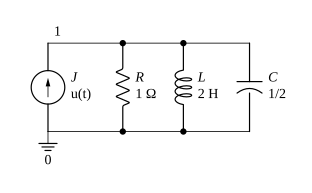

In [38]:
c14 = '''
j,0,1,u(t)
r,1,0,1
l,1,0,2,0
c,1,0,1/2,0
'''
draw(c14)

In [39]:
r14 = tr(c14)
r14

Result(domain='tr')
  i_c = (1 - t)*exp(-t)
  i_j = 1
  i_l = (-t + exp(t) - 1)*exp(-t)
  i_r = 2*t*exp(-t)
  v_1 = 2*t*exp(-t)

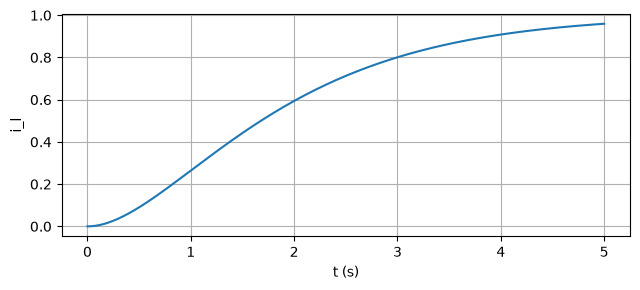

In [40]:
ts, ys = time_samples(c14, 'i_l', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 15. Bo2's Figure 6.23 (Op Amp)

An op amp with two capacitors and a unit-step input: find vo(t) — a decaying sinusoid settling to 1.

![The circuit of Bo2's Figure 6.23 (Op Amp)](https://learn.symbulator.com/assets/practice/bo2s-figure-6-23-op-amp-42.jpg)

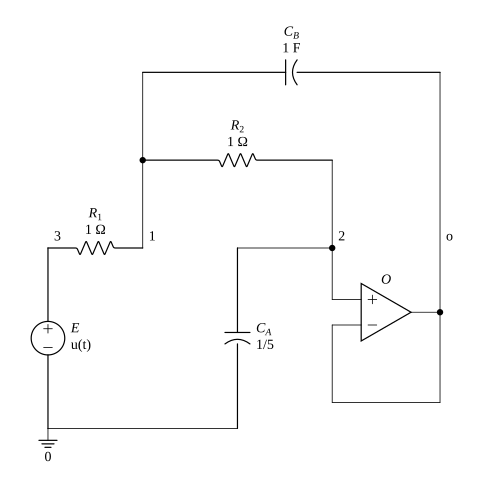

In [41]:
c15 = '''
e,3,0,u(t)
r1,3,1,1
r2,1,2,1
ca,2,0,1/5,0
cb,1,o,1,0
o,2,o,o
'''
draw(c15)

In [42]:
r15 = tr(c15)
r15

Result(domain='tr')
  i_ca = exp(-t)*sin(2*t)/2
  i_cb = (-sin(2*t)/2 + cos(2*t))*exp(-t)
  i_e = -exp(-t)*cos(2*t)
  i_o = (sin(2*t)/2 - cos(2*t))*exp(-t)
  i_r1 = exp(-t)*cos(2*t)
  i_r2 = exp(-t)*sin(2*t)/2
  v_1 = 1 - exp(-t)*cos(2*t)
  v_2 = (exp(t) - sin(2*t)/2 - cos(2*t))*exp(-t)
  v_3 = 1
  v_o = (exp(t) - sin(2*t)/2 - cos(2*t))*exp(-t)

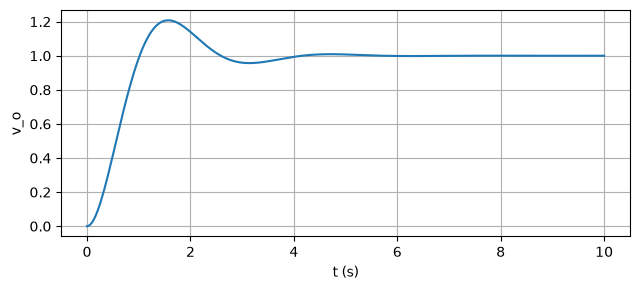

In [43]:
ts, ys = time_samples(c15, 'v_o', 10, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

## 16. Bo2's Drill Exercise 6.10 (Op Amp)

The circuit above with ca changed to 25/16 F and a 3 V step: find vo(t).

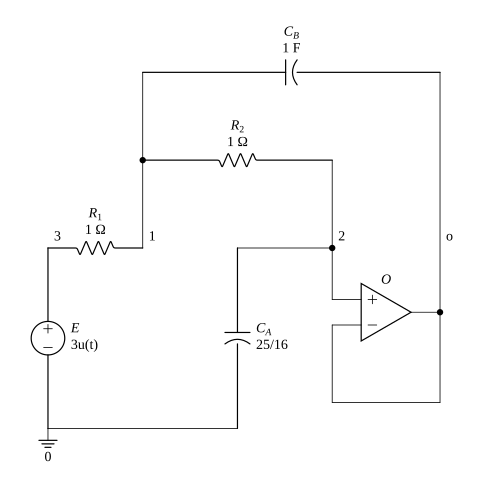

In [44]:
c16 = '''
e,3,0,3*u(t)
r1,3,1,1
r2,1,2,1
ca,2,0,25/16,0
cb,1,o,1,0
o,2,o,o
'''
draw(c16)

In [45]:
r16 = tr(c16)
r16

Result(domain='tr')
  i_ca = (5*exp(6*t/5) - 5)*exp(-8*t/5)/2
  i_cb = (4 - exp(6*t/5))*exp(-8*t/5)
  i_e = -(3*exp(6*t/5) + 3)*exp(-8*t/5)/2
  i_o = (exp(6*t/5) - 4)*exp(-8*t/5)
  i_r1 = 3*(exp(6*t/5) + 1)*exp(-8*t/5)/2
  i_r2 = (5*exp(6*t/5) - 5)*exp(-8*t/5)/2
  v_1 = 3 - 3*exp(-2*t/5)/2 - 3*exp(-8*t/5)/2
  v_2 = 3 - 4*exp(-2*t/5) + exp(-8*t/5)
  v_3 = 3
  v_o = 3 - 4*exp(-2*t/5) + exp(-8*t/5)

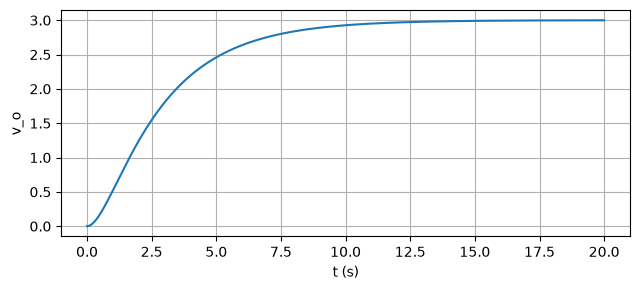

In [46]:
ts, ys = time_samples(c16, 'v_o', 20, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

## 17. Bo2's Drill Exercise 6.11 (p307)

An exponential source, 2e^(-2t), on a second-order circuit: find i(t) — read il.

![The circuit of Bo2's Drill Exercise 6.11 (p307)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-11-p307-43.jpg)

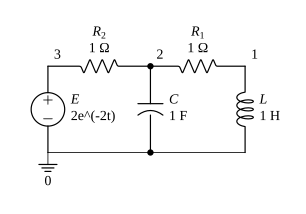

In [47]:
c17 = '''
e,3,0,2e^(-2t)
r2,3,2,1
r1,2,1,1
c,2,0,1,0
l,1,0,1,0
'''
draw(c17)

In [48]:
r17 = tr(c17)
r17

Result(domain='tr')
  i_c = 2*(-exp(t)*sin(t) + 1)*exp(-2*t)
  i_e = (sqrt(2)*exp(t)*sin(t + pi/4) - 3)*exp(-2*t)
  i_l = (-sqrt(2)*exp(t)*cos(t + pi/4) + 1)*exp(-2*t)
  i_r1 = (-sqrt(2)*exp(t)*cos(t + pi/4) + 1)*exp(-2*t)
  i_r2 = (-sqrt(2)*exp(t)*sin(t + pi/4) + 3)*exp(-2*t)
  v_1 = 2*(exp(t)*cos(t) - 1)*exp(-2*t)
  v_2 = (sqrt(2)*exp(t)*sin(t + pi/4) - 1)*exp(-2*t)
  v_3 = 2*exp(-2*t)

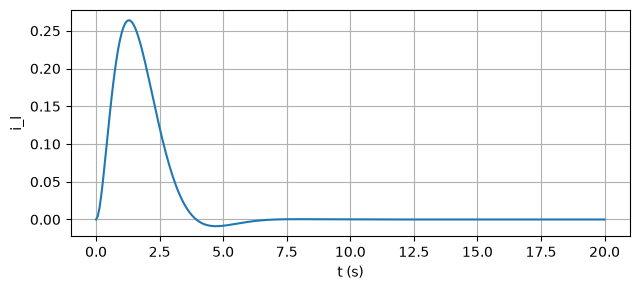

In [49]:
ts, ys = time_samples(c17, 'i_l', 20, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 18. A more complex problem (DC)

Professor Boulet's exam problem, from her circuits class at UTP. First interval in DC: the two capacitors sit at 9 V and 9/4 V.

![The circuit of A more complex problem (DC)](https://learn.symbulator.com/assets/practice/a-more-complex-problem-44.png)

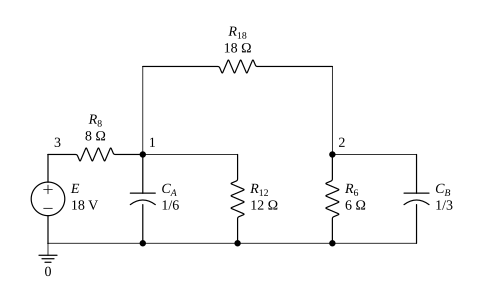

In [50]:
c18 = '''
e,3,0,18
r8,3,1,8
ca,1,0,1/6
r12,1,0,12
r18,1,2,18
r6,2,0,6
cb,2,0,1/3
'''
draw(c18)

In [51]:
r18 = dc(c18)
r18

Result(domain='dc')
  i_ca = 0
  i_cb = 0
  i_e = -9/8
  i_r12 = 3/4
  i_r18 = 3/8
  i_r6 = 3/8
  i_r8 = 9/8
  p_ca = 0
  p_cb = 0
  p_e = -81/4
  p_r12 = 27/4
  p_r18 = 81/32
  p_r6 = 27/32
  p_r8 = 81/8
  r_e = 16
  v_1 = 9
  v_2 = 9/4
  v_3 = 18
  v_ca = 9
  v_cb = 9/4
  v_e = 18
  v_r12 = 9
  v_r18 = 27/4
  v_r6 = 9/4
  v_r8 = 9

## 19. A more complex problem (TR)

Find v1 and v2 with the damped sinusoidal source connected; the limited-results box asks for just those two. Professor Boulet's problem. Seventy-eight seconds on the calculator; about a second here.

![The circuit of A more complex problem (TR)](https://learn.symbulator.com/assets/practice/a-more-complex-problem-44.png)

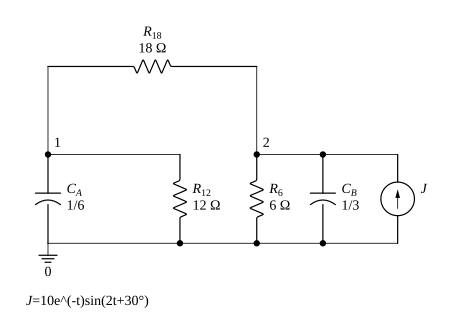

In [52]:
c19 = '''
ca,1,0,1/6,9
r12,1,0,12
r18,1,2,18
r6,2,0,6
cb,2,0,1/3,9/4
j,0,2,10e^(-t)*sin(2t+30*pi/180)
'''
draw(c19)

In [53]:
r19 = tr(c19, variables=['v_1', 'v_2'])
r19

Result(domain='tr')
  v_1 = ((-80*sin(2*t + pi/6) + 20*cos(2*t + pi/6) - 170*sqrt(3) + 153)*exp(t/2) + (193 + 160*sqrt(3))*exp(t))*exp(-3*t/2)/34
  v_2 = ((-160*sin(2*t + pi/6) - 980*cos(2*t + pi/6) - 153 + 170*sqrt(3))*exp(t/2) + 2*(193 + 160*sqrt(3))*exp(t))*exp(-3*t/2)/68

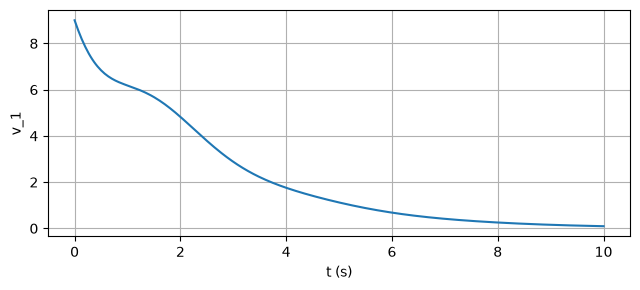

In [54]:
ts, ys = time_samples(c19, 'v_1', 10, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_1'); plt.grid(True); plt.tight_layout()

## 20. Bo2's Drill Exercise 4.5 (Expert)

Expert Mode in TR: the step value a is the unknown, and the known answer 1-e^(-t/2) = vc is the extra equation. Find vr, ic and the source's value, which is 1 V. Everything typed into Expert Mode in version 9 is read in the time domain, so the answer you know goes in as you would write it on paper.

![The circuit of Bo2's Drill Exercise 4.5 (Expert)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-4-5-expert-45.png)

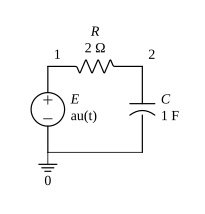

In [55]:
c20 = '''
e,1,0,a*u(t)
r,1,2,2
c,2,0,1,0
'''
draw(c20)

In [56]:
r20 = tr(c20, equations=['1-e^(-t/2) = v_c'], unknowns=['a'])
r20

Result(domain='tr')
  a = 1
  i_c = exp(-t/2)/2
  i_e = -exp(-t/2)/2
  i_r = exp(-t/2)/2
  v_1 = 1
  v_2 = 1 - exp(-t/2)
  v_c = 1 - exp(-t/2)

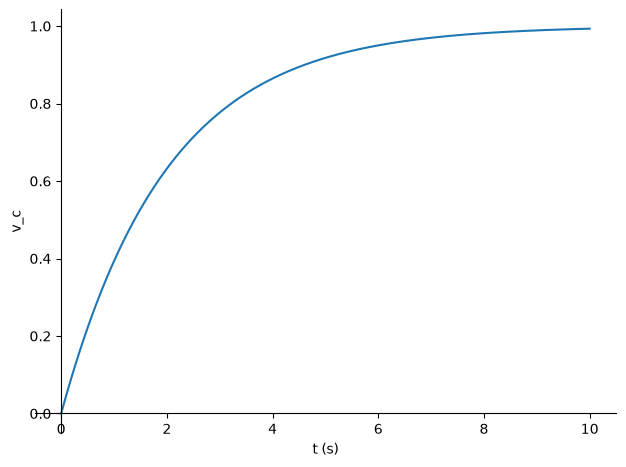

In [57]:
d = tr(c20, variables=['v_2'], equations=['1-e^(-t/2) = v_c'], unknowns=['a'])
sp.plot(d['v_2'] - 0, (t, 0, 10), xlabel='t (s)', ylabel='v_c');

## 21. Bo2's Drill Exercise 4.13 (Expert)

The same trick: vs is unknown and vr = e^(-t) is known. The source turns out to be 1 V.

![The circuit of Bo2's Drill Exercise 4.13 (Expert)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-4-13-expert-46.png)

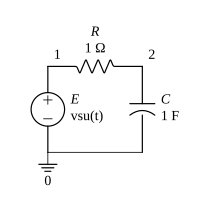

In [58]:
c21 = '''
e,1,0,vs*u(t)
r,1,2,1
c,2,0,1,0
'''
draw(c21)

In [59]:
r21 = tr(c21, equations=['v_r = e^(-t)'], unknowns=['vs'])
r21

Result(domain='tr')
  i_c = exp(-t)
  i_e = -exp(-t)
  i_r = exp(-t)
  v_1 = 1
  v_2 = 1 - exp(-t)
  v_r = exp(-t)
  vs = 1

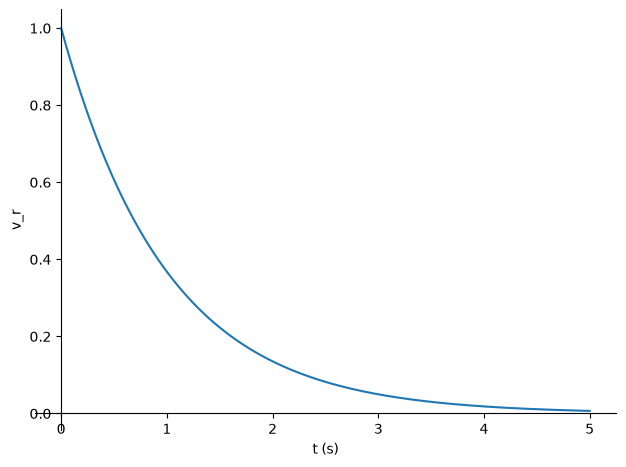

In [60]:
d = tr(c21, variables=['v_1', 'v_2'], equations=['v_r = e^(-t)'], unknowns=['vs'])
sp.plot(d['v_1'] - d['v_2'], (t, 0, 5), xlabel='t (s)', ylabel='v_r');

## 22. Bo2's 164 (Expert)

The RL version: vs is unknown and il = 1-e^(-2t) is known. The source turns out to be 2 V.

![The circuit of Bo2's 164 (Expert)](https://learn.symbulator.com/assets/practice/bo2s-164-expert-47.png)

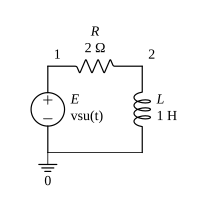

In [61]:
c22 = '''
e,1,0,vs*u(t)
r,1,2,2
l,2,0,1,0
'''
draw(c22)

In [62]:
r22 = tr(c22, equations=['1-e^(-2*t) = i_l'], unknowns=['vs'])
r22

Result(domain='tr')
  i_e = -1 + exp(-2*t)
  i_l = 1 - exp(-2*t)
  i_r = 1 - exp(-2*t)
  v_1 = 2
  v_2 = 2*exp(-2*t)
  vs = 2

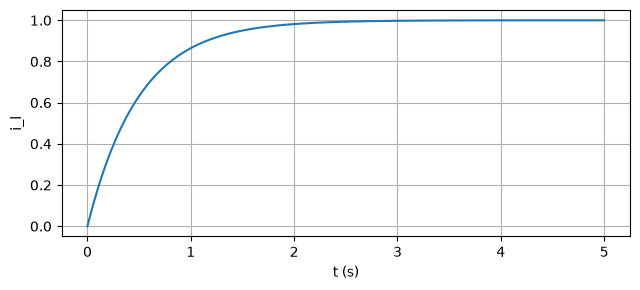

In [63]:
ts, ys = time_samples(c22, 'i_l', 5, t_min=0, n=300, equations=['1-e^(-2*t) = i_l'], unknowns=['vs'])
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()